In [130]:
import pandas as pd
import numpy as np
import keras
from keras import layers
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor

## Spliting dataset

In [131]:
nvidia_stock = pd.read_csv("../../../data/data_stooq/daily/us/nasdaq stocks/2/nvda.us.txt")
nvidia_stock.head(2)

,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>,<OPENINT>
0,NVDA.US,D,19990122,0,0.040127,0.044710,0.035533,0.037602,740416863,0
1,NVDA.US,D,19990125,0,0.040586,0.041963,0.037602,0.041499,139413824,0


In [132]:
## Data preprocessing
rename_dict = {}
for col in nvidia_stock.columns:
    rename_dict[col] = col.strip("<>")
    
# display(rename_dict)
nvidia_stock = nvidia_stock.rename(columns = rename_dict)
# display(nvidia_stock.describe())
# DROPING OPENINT COLUMN
nvidia_stock = nvidia_stock.drop(columns=["OPENINT", "TICKER", "PER", "TIME"])
nvidia_stock["DATE"] = pd.to_datetime(nvidia_stock["DATE"], format="%Y%m%d")
nvidia_stock["LOG_CLOSE_RETURN"] = np.log(nvidia_stock["CLOSE"] / nvidia_stock["CLOSE"].shift(1))

# Drop NaN from LOG_CLOSE_RETURN
nvidia_stock = nvidia_stock.dropna().reset_index(drop=True)

nvidia_stock.head(2)

,DATE,OPEN,HIGH,LOW,CLOSE,VOL,LOG_CLOSE_RETURN
0,1999-01-25,0.040586,0.041963,0.037602,0.041499,139413824,0.098620
1,1999-01-26,0.041963,0.042876,0.037839,0.038287,93919355,-0.080567


In [133]:
# Time-based split (80% train, 10% validation, 10% test) - no shuffling for time series
nvidia_stock = nvidia_stock.sort_values("DATE").reset_index(drop=True)

n = len(nvidia_stock)
train_size = int(n * 0.8)
val_size = int(n * 0.1)

train_nvidia_stock = nvidia_stock.iloc[:train_size].copy()
validation_nvidia_stock = nvidia_stock.iloc[train_size:train_size + val_size].copy()
test_nvidia_stock = nvidia_stock.iloc[train_size + val_size:].copy()

print(f"Dataset size: {len(nvidia_stock)}")
print(f"Train size: {len(train_nvidia_stock)}")
print(f"Validation size: {len(validation_nvidia_stock)}")
print(f"Test size: {len(test_nvidia_stock)}")
print(f"Train date range: {train_nvidia_stock['DATE'].min()} to {train_nvidia_stock['DATE'].max()}")
print(f"Validation date range: {validation_nvidia_stock['DATE'].min()} to {validation_nvidia_stock['DATE'].max()}")
print(f"Test date range: {test_nvidia_stock['DATE'].min()} to {test_nvidia_stock['DATE'].max()}")

Dataset size: 6810
Train size: 5448
Validation size: 681
Test size: 681
Train date range: 1999-01-25 00:00:00 to 2020-09-17 00:00:00
Validation date range: 2020-09-18 00:00:00 to 2023-06-02 00:00:00
Test date range: 2023-06-05 00:00:00 to 2026-02-20 00:00:00


In [134]:
## Cyclical encoding for DATE (applied to each split separately)
def add_cyclical_features(df):
    df = df.copy()
    df['day_of_year'] = df['DATE'].dt.dayofyear
    df['month'] = df['DATE'].dt.month
    df['day_of_week'] = df['DATE'].dt.dayofweek

    df['sin_doy'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['cos_doy'] = np.cos(2 * np.pi * df['day_of_year'] / 365)
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
    df['sin_dow'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['cos_dow'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    df = df.drop(columns=['DATE', 'day_of_year', 'month', 'day_of_week'])
    return df

train_nvidia_stock = add_cyclical_features(train_nvidia_stock)
validation_nvidia_stock = add_cyclical_features(validation_nvidia_stock)
test_nvidia_stock = add_cyclical_features(test_nvidia_stock)

print("Columns after encoding:", train_nvidia_stock.columns.tolist())
print(train_nvidia_stock.head(2))

Columns after encoding: ['OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL', 'LOG_CLOSE_RETURN', 'sin_doy', 'cos_doy', 'sin_month', 'cos_month', 'sin_dow', 'cos_dow']
       OPEN      HIGH       LOW     CLOSE        VOL  LOG_CLOSE_RETURN  \
0  0.040586  0.041963  0.037602  0.041499  139413824          0.098620   
1  0.041963  0.042876  0.037839  0.038287   93919355         -0.080567   

    sin_doy   cos_doy  sin_month  cos_month   sin_dow  cos_dow  
0  0.417194  0.908818        0.5   0.866025  0.000000  1.00000  
1  0.432776  0.901502        0.5   0.866025  0.781831  0.62349  


## Convert train, test, validation into X, y for models

In [135]:
def make_windows(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
    window_days: int,
    horizon_days: int = 1,
) -> tuple[np.ndarray, np.ndarray]:
    values = df[feature_cols].to_numpy()
    targets = df[target_col].to_numpy()
 
    n = len(df)
    X, y = [], []
 
    # last valid window: context ends at index i, target is at i + horizon_days
    last_start = n - window_days - horizon_days
    for start in range(0, last_start + 1):
        context_end = start + window_days  # exclusive
        last_context_idx = context_end - 1
 
        context = values[start:context_end]
        target = targets[last_context_idx + 1 : last_context_idx + 1 + horizon_days].sum()
 
        X.append(context)
        y.append(target)
 
    return np.array(X), np.array(y)

In [136]:
features_chosen = ['LOG_CLOSE_RETURN', 'sin_doy', 'cos_doy', 'sin_month', 'cos_month', 'sin_dow', 'cos_dow']

X_train, y_train = make_windows(df = train_nvidia_stock,
                                   feature_cols = features_chosen,
                                   target_col='LOG_CLOSE_RETURN',
                                   window_days=30)

X_val, y_val = make_windows(df = validation_nvidia_stock,
                                   feature_cols = features_chosen,
                                   target_col='LOG_CLOSE_RETURN',
                                   window_days=30)

X_test, y_test = make_windows(df = test_nvidia_stock,
                                   feature_cols = features_chosen,
                                   target_col='LOG_CLOSE_RETURN',
                                   window_days=30)

print(type(X_train))
print(X_train.shape)
print(y_train.shape)

<class 'numpy.ndarray'>
(5418, 30, 7)
(5418,)


## Model definition

In [137]:
RNN_model = keras.Sequential(
    [
        layers.Input(shape=(30, len(features_chosen))),
        layers.SimpleRNN(32),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ]
)

RNN_model.compile(optimizer="adam", loss="mse")

In [138]:
LSTM_model = keras.Sequential(
    [
        layers.Input(shape=(30, len(features_chosen))),
        layers.LSTM(32),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ]
)

LSTM_model.compile(optimizer="adam", loss="mse")

## Model Training

In [139]:
# Train RNN
print("Training RNN...")
rnn_history = RNN_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
)

# Train LSTM
print("Training LSTM...")
lstm_history = LSTM_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
)

Training RNN...
Epoch 1/20


170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0366 - val_loss: 0.0041
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0039 - val_loss: 0.0026
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0029 - val_loss: 0.0020
Epoch 4/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0025 - val_loss: 0.0017
Epoch 5/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 6/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0021 - val_loss: 0.0016
Epoch 7/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0020 - val_loss: 0.0019
Epoch 8/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0020 - val_loss: 0.0017
Epoch 9/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0020 - val_loss: 0.0016
Epoch 10/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0019 - val_loss: 0.0015
Epoch 11/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 12/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.

## Evaluation & Visualization

RNN         - MSE: 0.001272, MAE: 0.027349
LSTM        - MSE: 0.000931, MAE: 0.022159
Dummy (mean)- MSE: 0.000911, MAE: 0.021856


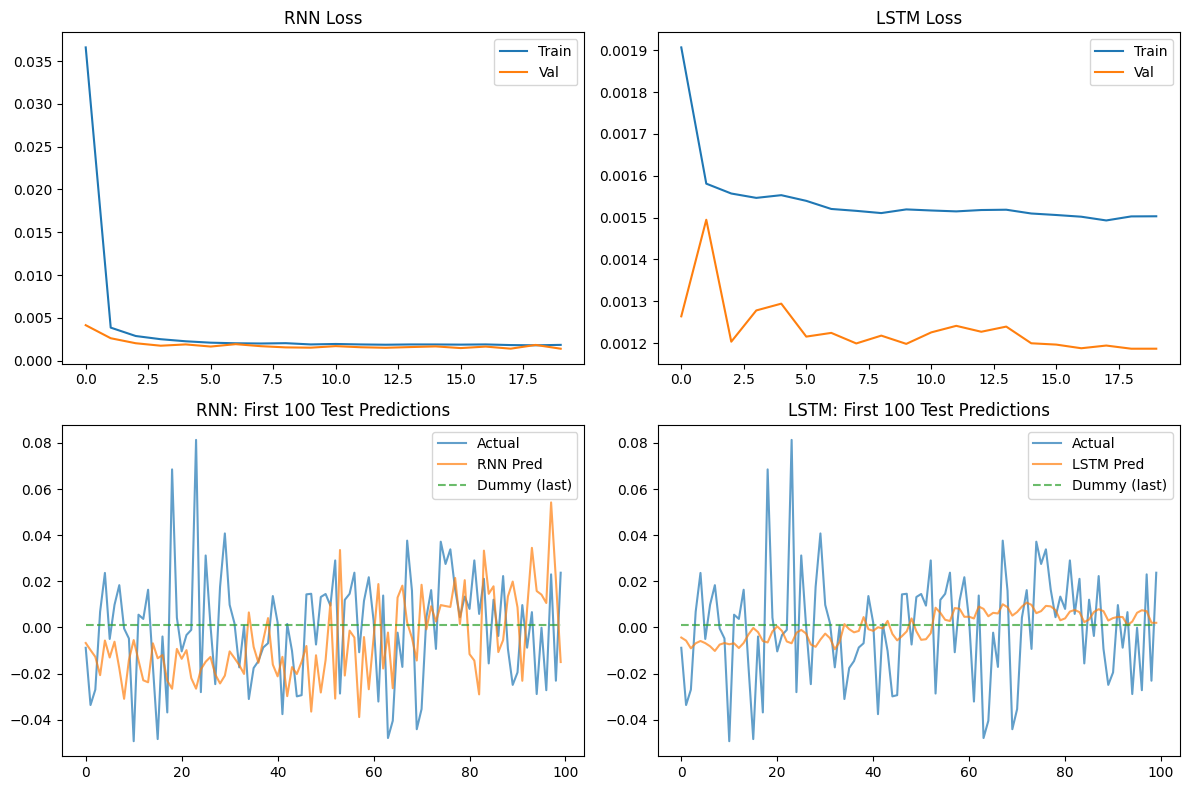

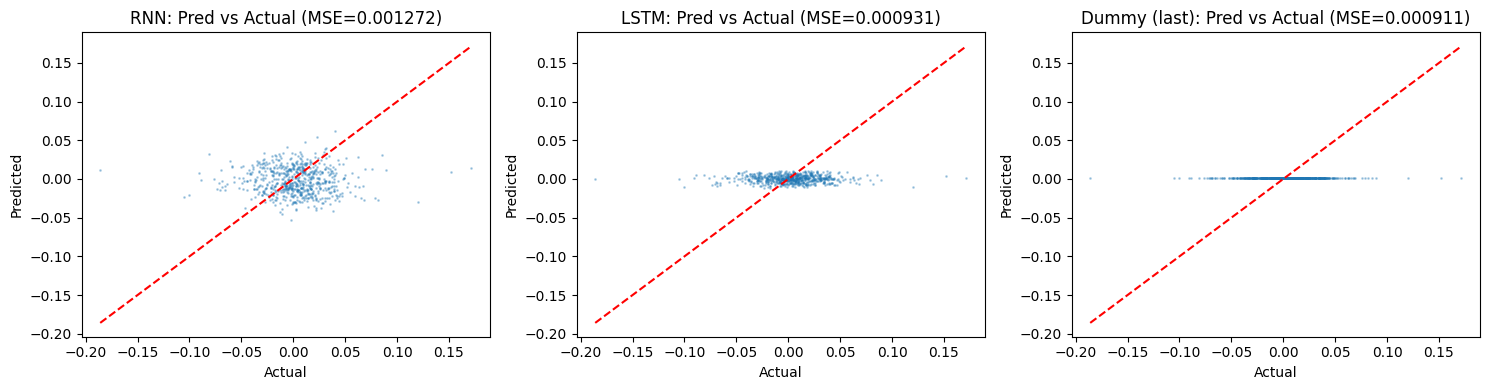

In [140]:
dummy_mean = DummyRegressor(strategy="mean")  # predict mean of train
dummy_mean.fit(X_train, y_train)

dummy_mean_pred = dummy_mean.predict(X_test)

# Model predictions
rnn_pred = RNN_model.predict(X_test, verbose='0').flatten()
lstm_pred = LSTM_model.predict(X_test, verbose='0').flatten()

# Metrics
rnn_mse = mean_squared_error(y_test, rnn_pred)
rnn_mae = mean_absolute_error(y_test, rnn_pred)
lstm_mse = mean_squared_error(y_test, lstm_pred)
lstm_mae = mean_absolute_error(y_test, lstm_pred)
dummy_mean_mse = mean_squared_error(y_test, dummy_mean_pred)
dummy_mean_mae = mean_absolute_error(y_test, dummy_mean_pred)

print(f"RNN         - MSE: {rnn_mse:.6f}, MAE: {rnn_mae:.6f}")
print(f"LSTM        - MSE: {lstm_mse:.6f}, MAE: {lstm_mae:.6f}")
print(f"Dummy (mean)- MSE: {dummy_mean_mse:.6f}, MAE: {dummy_mean_mae:.6f}")

# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Loss curves
axes[0, 0].plot(rnn_history.history['loss'], label='Train')
axes[0, 0].plot(rnn_history.history['val_loss'], label='Val')
axes[0, 0].set_title('RNN Loss')
axes[0, 0].legend()

axes[0, 1].plot(lstm_history.history['loss'], label='Train')
axes[0, 1].plot(lstm_history.history['val_loss'], label='Val')
axes[0, 1].set_title('LSTM Loss')
axes[0, 1].legend()

# Predictions vs Actual
axes[1, 0].plot(y_test[:100], label='Actual', alpha=0.7)
axes[1, 0].plot(rnn_pred[:100], label='RNN Pred', alpha=0.7)
axes[1, 0].plot(dummy_mean_pred[:100], label='Dummy (last)', alpha=0.7, linestyle='--')
axes[1, 0].set_title('RNN: First 100 Test Predictions')
axes[1, 0].legend()

axes[1, 1].plot(y_test[:100], label='Actual', alpha=0.7)
axes[1, 1].plot(lstm_pred[:100], label='LSTM Pred', alpha=0.7)
axes[1, 1].plot(dummy_mean_pred[:100], label='Dummy (last)', alpha=0.7, linestyle='--')
axes[1, 1].set_title('LSTM: First 100 Test Predictions')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Scatter plot: predicted vs actual
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(y_test, rnn_pred, alpha=0.3, s=1)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'RNN: Pred vs Actual (MSE={rnn_mse:.6f})')

axes[1].scatter(y_test, lstm_pred, alpha=0.3, s=1)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'LSTM: Pred vs Actual (MSE={lstm_mse:.6f})')

axes[2].scatter(y_test, dummy_mean_pred, alpha=0.3, s=1)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title(f'Dummy (last): Pred vs Actual (MSE={dummy_mean_mse:.6f})')

plt.tight_layout()
plt.show()

In [141]:
# does RNN's prediction correlate more with cyclical features than with true returns?
print("RNN pred vs y_test correlation:", np.corrcoef(rnn_pred, y_test)[0,1])
print("LSTM pred vs y_test correlation:", np.corrcoef(lstm_pred, y_test)[0,1])

RNN pred vs y_test correlation: -0.03987192647601367
LSTM pred vs y_test correlation: 0.014084740480987491
